<a href="https://colab.research.google.com/github/q0524/Colab_deeplearning_try/blob/25-1-%ED%8D%BC%EC%8A%A4%EB%84%90AI/%ED%8D%BC%EC%8A%A4%EB%84%90ai_%EB%A0%88%ED%8F%AC%ED%8A%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

다음 조건을 충족하는 RNN 기반 예측 모델을 구현하고, 결과를 분석하여 레포트로 제출하세요.

여름이 다가오고 있는 지금 장마철 기간 및 강우량을 조사하여 미리 대비할 수 있도록 예측하는 인공지능 만들기

장마는 우리나라 6월 하순부터 7월 하순까지 계속해서 많이 내리는 비로 기상학적으로는 장마전선의 영향을 받아 비가 오는 경우를 의미합니다.

---
1961 - 2024까지 장마 자료를 이용하여 2025년 장마 강수량, 시기 예측 인공지능 만들기 2년의 자료를 이용하여 다음 년도의 강수량을 입력하고 이에 따라 2025년에는 2018년 자료부터 2024년 자료를 이용하여 2025년도 예측을 최종적으로 해보는 알고리즘 및 인공지능 제작

***개발도구 가져오기***

In [ ]:
# 인공지능 제작에 필요한 함수들 import
from keras.models import Sequential
from keras.layers import SimpleRNN, LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from google.colab import files

In [ ]:
# csv 파일 불러오기
uploaded = files.upload()

Saving STCS_rainy_season.csv to STCS_rainy_season.csv


***데이터 가져오기***

In [ ]:
# 업로드된 파일 이름 확인 및 사용
filename = list(uploaded.keys())[0]

# CSV 파일 읽기
dataframe = pd.read_csv('STCS_rainy_season.csv', engine='python', encoding='euc-kr', sep='\t')

# 데이터 미리보기
dataframe.head()

,[검색조건]
0,"기간 : 1961~2024년,비교연도: 2025"
1,[장마평년값]
2,"지역,시작일,종료일,기간(일),강수일수(일),평균강수량(mm)"
3,"중부지방,06.25.,07.26.,31.5,17.7,378.3"
4,"남부지방,06.23.,07.24.,31.4,17.0,341.1"


In [ ]:
# 전체 데이터셋 확인 / 앞에서 10행의 값을 출력을 통해 확인
alldata = pd.read_csv('/content/STCS_rainy_season.csv', engine = 'python', encoding='euc-kr', sep='\t', skipfooter=3) # 또는 'euc-kr'

# 앞에서 10행의 값 출력
alldata.head(10,)

,[검색조건]
0,"기간 : 1961~2024년,비교연도: 2025"
1,[장마평년값]
2,"지역,시작일,종료일,기간(일),강수일수(일),평균강수량(mm)"
3,"중부지방,06.25.,07.26.,31.5,17.7,378.3"
4,"남부지방,06.23.,07.24.,31.4,17.0,341.1"
5,"제주지방,06.19.,07.20.,32.4,17.5,348.7"
6,[전국 강수량 및 강수일수]
7,"연도,강수량(mm),강수일수"
8,"1961,224.2,12.2"
9,"1962,194.3,14.4"


In [ ]:
# 뒤에서 15행의 값을 출력을 통해 확인
dataframe.tail(15,)

,[검색조건]
89,"구분,중부,남부,제주도"
90,"가장 빠른 해,1970-06-14,2011-06-10,2020-06-10"
91,"가장 늦은 해,1982-07-10,1992-07-09,1982-07-05"
92,"2025,,,"
93,[지역별 종료일 분석]
94,"구분,중부,남부,제주도"
95,"가장 빠른 해,1973-06-30,1973-06-30,1994-07-01"
96,"가장 늦은 해,2020-08-16,1969-08-11,1969-08-07"
97,"2025,,,"
98,[지역별 기간 분석]


파일은 총 102행으로 구성되어 있고, 컬럼(열)은 1개뿐이다.

그 열의 이름은 '검색조건'이며, 모든 데이터는 문자열(object) 형태로 저장 되어있다.

In [ ]:
# 전체 데이터의 정보
alldata.info()

# 전체 데이터의 통계
alldata.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   [검색조건]  102 non-null    object
dtypes: object(1)
memory usage: 948.0+ bytes


,[검색조건]
count,102
unique,100
top,"2025,,,"
freq,2


***데이터 정규화 및 분류***

필요한 값 만을 가져오도록 불필요한 값 제거 및 변수 새로 정의

alldataset에 존재하던 불필요한 값 제거

스케일링을 통해 인공지능 모델의 성능을 높이도록 설정

In [ ]:
# dataset_1이라는 새로운 변수를 지정하여 맨 앞부터 7번째 행, 맨 뒤부터 43째 행까지 삭제
dataset_1 = alldata.drop(index=range(0, 8)).reset_index(drop=True)
dataset_1 = dataset_1.iloc[:-44].reset_index(drop=True)

# ','를 기준으로 0,1 열 분리
dataset_1 = dataset_1[dataset_1.columns[0]].str.split(',', expand=True)

# 첫 번째 열(0번 열) 삭제
dataset_1 = dataset_1.drop(dataset_1.columns[0], axis=1)

# 데이터 확인
dataset_1.head(10)

,1,2
0,224.2,12.2
1,194.3,14.4
2,542.6,22.8
3,258.8,14
4,498.5,20.4
5,401.3,19.4
6,301.9,15.9
7,180.1,10.6
8,550.2,28.6
9,476.8,21.8


In [ ]:
# 2차원 배열로 설정 후 더 좋은 성능의 모델링을 위한 데이터 정규화
dataset = dataset_1.astype('float32').values

# 각 열마다 인공지능에 사용하기 위해 변수를 이용하여 열 분류
rain = dataset[:, 0].reshape(-1, 1)
year = dataset[:, 1].reshape(-1, 1)

# 데이터셋 확인
print(rain[:5])
print("----------")
print(year[:5])

[[224.2]
 [194.3]
 [542.6]
 [258.8]
 [498.5]]
----------
[[12.2]
 [14.4]
 [22.8]
 [14. ]
 [20.4]]


In [ ]:
# 정규화 객체 선언, 예측할 변수만 따로 스케일링, 각 변수별로 scaler 따로 선언
rain_scaler = MinMaxScaler()
year_scaler = MinMaxScaler()

# 정규화된 데이터 선언 scaler = s로 축약, 데이터셋을 나누어 스케일링 할 수 있도록 미리 설정
s_rain = rain_scaler.fit_transform(rain)
s_year = year_scaler.fit_transform(year)

# 정규화 된 강수량 데이터 출력
print(s_rain[:5])
print("---------------")
print(s_year[:5])

[[0.23671651]
 [0.18915048]
 [0.7432389 ]
 [0.29175943]
 [0.67308307]]
---------------
[[0.31950206]
 [0.41078836]
 [0.759336  ]
 [0.39419085]
 [0.659751  ]]


In [ ]:
# 훈련 데이터와 검증 데이터 분리 및 출력
train_rain, test_rain = train_test_split(s_rain, test_size=0.2, shuffle=False)
train_year, test_year = train_test_split(s_year, test_size=0.2, shuffle=False)

print(len(train_rain),len(test_rain))
print(len(train_year),len(test_year))

40 10
40 10


***데이터 형태 변경***

연속된 데이터를 사용하여 이전 4년치 데이터를 사용하여 5번째 년도의 강수량을 예측하는 방식

1줄로 나열된 데이터에서 연속된 데이터의 형태로 바꾸어 주는 과정 필요

ex) 1961년부터 1964년까지의 데이터를 x_data에 넣고 그 다음 5년차 데이터인 1965년 데이터를 y_data에 넣는 형식

---
***2차원 데이터를 3차원 데이터로 변경***

2차원 데이터를 활용하는 것과 3차원 데이터를 활용하는 것은 분명한 차이 존재

=> 각각의 4년치 데이터를 학습해야하기 때문에 변경 필요

In [ ]:
# RNN(순환신경망)으로 예측 만들기 (4년치 데이터로 이후 1년 예측)
def create_dataset(data, look_back):
  x_data = []
  y_data = []
  for i in range(len(data)-look_back-1):
    x_data.append(data[i:(i+look_back),0])
    y_data.append(data[i + look_back, 0])
  return np.array(x_data), np.array(y_data)

# 5년치 데이터(look_back = 5)로 예측 데이터 설계
look_back = 5

# 훈련, 검증 데이터 생성
x_rain, y_rain = create_dataset(train_rain, look_back)
x_year, y_year = create_dataset(train_year, look_back)
x_test_rain, y_test_rain = create_dataset(test_rain, look_back)
x_test_year, y_test_year = create_dataset(test_year, look_back)

# 훈련, 검증 데이터 연도 모습 살펴보기
print(x_year.shape, y_year.shape)
print(x_test_year.shape, y_test_year.shape)

(34, 5) (34,)
(4, 5) (4,)


In [ ]:
# 2차원 데이터를 3차원 데이터로 변경
X_rain = np.reshape(x_rain, (x_rain.shape[0], look_back, 1))
X_year = np.reshape(x_year, (x_year.shape[0], look_back, 1))
X_test_rain = np.reshape(x_test_rain, (x_test_rain.shape[0], look_back, 1))
X_test_year = np.reshape(x_test_year, (x_test_year.shape[0], look_back, 1))

print(X_rain.shape)
print(X_test_rain.shape)

(34, 5, 1)
(4, 5, 1)


***인공지능 모델 만들기***

첫 번째 데이터를 얺고 은닉 층에 있는 파라미터(가중치,편향)값을 학습하고 다음 단계로 넘겨주기 ~2,3년치~ 반복 이후 결과값과 4번째 데이터를 넣고 최종값을 예측

In [ ]:
# 모델 만들기
def build_model():
    model = Sequential()
    model.add(SimpleRNN(10, input_shape=(look_back, 1), return_sequences=True))
    model.add(Dropout(0.2))
    model.add(SimpleRNN(5))
    model.add(Dropout(0.2))
    model.add(Dense(1, activation='linear'))
    model.compile(loss='mse', optimizer='adam')
    return model

model_rain = build_model()
model_year = build_model()

model_rain.summary()
model_year.summary()

Model: "sequential_56"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_54 (SimpleRNN)       │ (None, 5, 10)          │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_78 (Dropout)            │ (None, 5, 10)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_55 (SimpleRNN)       │ (None, 5)              │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_79 (Dropout)            │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 206 (824.00 B)

 Trainable params: 206 (824.00 B)

 Non-trainable params: 0 (0.00 B)

Model: "sequential_57"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_56 (SimpleRNN)       │ (None, 5, 10)          │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_80 (Dropout)            │ (None, 5, 10)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_57 (SimpleRNN)       │ (None, 5)              │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_81 (Dropout)            │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 206 (824.00 B)

 Trainable params: 206 (824.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 인공지능 모델 만들기,
# 데이터를 이용하여, 반복횟수(epochs), 1번 당 학습시킬 데이터의 양을 (batch_size=1)로 설정
# verbose를 통해 에포크별 진행 사항 간단히 알려주기
model_rain.fit(X_rain, y_rain, epochs=100, batch_size=5, verbose=1)
model_year.fit(X_year, y_year, epochs=100, batch_size=5, verbose=1)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0554
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0429 
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0412
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0537
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0647 
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0426  
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0354 
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0410 
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0530 
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0544 
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0485 
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0441 
Epoch 13/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0392 
Epoch 14/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0370 
Epoch 15/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0602 
Epoch 16/100
7/7

***데이터 예측하기***

정규화를 거친 결과 X ⇒ 실제 강수량 데이터가 필요

*모델을 통해 나온 예측 값을 정규화 이전 값으로 (스케일링을 통해) 변환 할 필요, 실제 값 또한 (스케일링을 통해) 변환



In [ ]:
# 인공지능의 결괏값 생성 후 예측값을 train(rain, day), test(rain, day)_Predict에 저장
trainRain_Predict = model_rain.predict(X_rain)
trainYear_Predict = model_year.predict(X_year)
testRain_Predict = model_rain.predict(X_test_rain)
testYear_Predict = model_year.predict(X_test_year)

# 스케일링 된 데이터(강수량의 정확도를 높이기 위한)를 원래 데이터로 변환
TrainRain_Predict = rain_scaler.inverse_transform(trainRain_Predict)
TrainYear_Predict = year_scaler.inverse_transform(trainYear_Predict)
TestRain_Predict = rain_scaler.inverse_transform(testRain_Predict)
TestYear_Predict = year_scaler.inverse_transform(testYear_Predict)

# 예측된 값과 실제를 원래 스케일로 돌려서 훈련은 Y_tarin(rain, day)에 실제 결과 값는 Y_test(rain, day)에 저장
Y_rain = rain_scaler.inverse_transform([y_rain])
Y_year = year_scaler.inverse_transform([y_year])
Y_test_rain = rain_scaler.inverse_transform([y_test_rain])
Y_test_year = year_scaler.inverse_transform([y_test_year])

# 훈련값 (강수량)출력
print(trainRain_Predict[:5])

# 스케일링 된(되돌린) 훈련값 출력
print(TrainRain_Predict[:5])

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 261ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
[[0.45955268]
 [0.39231217]
 [0.37851632]
 [0.41708443]
 [0.5055088 ]]
[[364.2748 ]
 [322.00745]
 [313.33536]
 [337.57925]
 [393.1628 ]]


In [ ]:
# 오차범위에 대해 점수로 출력
# rmse : 표준오차가 어느정도 되는가 %.2 : 소수점 2째자리 까지 보겠다
trainScore_rain = math.sqrt(mean_squared_error(Y_rain[0], TrainRain_Predict[:,0]))
print('Train Score_rain: %.2f RMSE' % (trainScore_rain))
trainScore_year = math.sqrt(mean_squared_error(Y_year[0], TrainYear_Predict[:,0]))
print('Train Score_rain: %.2f RMSE' % (trainScore_year))

testScore_rain = math.sqrt(mean_squared_error(Y_test_rain[0], TestRain_Predict[:,0]))
print('Test Score_year: %.2f RMSE' % (testScore_rain))
testScore_year = math.sqrt(mean_squared_error(Y_test_year[0], TestYear_Predict[:,0]))
print('Test Score_year: %.2f RMSE' % (testScore_year))

Train Score_rain: 124.68 RMSE
Train Score_rain: 5.26 RMSE
Test Score_year: 227.32 RMSE
Test Score_year: 5.51 RMSE


Train_rain Score: 124.68 RMSE
Test_rain Score: 227.32 RMSE


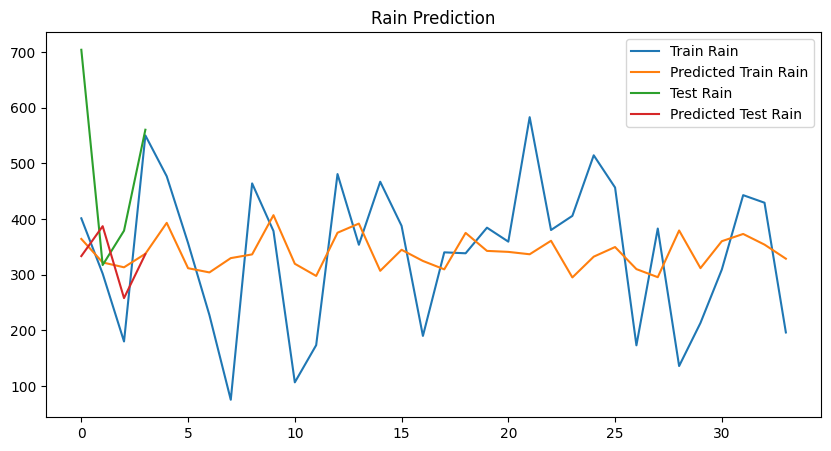

Train_year Score: 5.26 RMSE
Test_rain Score: 227.32 RMSE


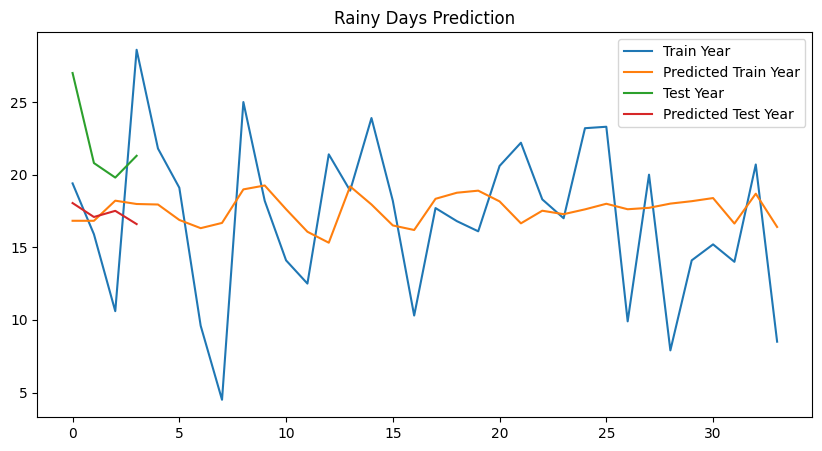

In [ ]:
# 강수량 차트 그리기 : 학습 구간
plt.figure(figsize=(10, 5))
plt.plot(Y_rain[0], label='Train Rain')
plt.plot(TrainRain_Predict[:, 0], label='Predicted Train Rain')
print('Train_rain Score: %.2f RMSE' % (trainScore_rain))

# 강수량 테스트 구간
plt.plot(Y_test_rain[0], label='Test Rain')
plt.plot(TestRain_Predict[:, 0], label='Predicted Test Rain')
print('Test_rain Score: %.2f RMSE' % (testScore_rain))
plt.title('Rain Prediction')
plt.legend()
plt.show()

# 연 장마 주기 차트 그리기 : 학습 구간
plt.figure(figsize=(10, 5))
plt.plot(Y_year[0], label='Train Year')
plt.plot(TrainYear_Predict[:, 0], label='Predicted Train Year')
print('Train_year Score: %.2f RMSE' % (trainScore_year))

# 연 장마 주기 테스트 구간
plt.plot(Y_test_year[0], label='Test Year')
plt.plot(TestYear_Predict[:, 0], label='Predicted Test Year')
print('Test_rain Score: %.2f RMSE' % (testScore_rain))
plt.title('Rainy Days Prediction')
plt.legend()
plt.show()

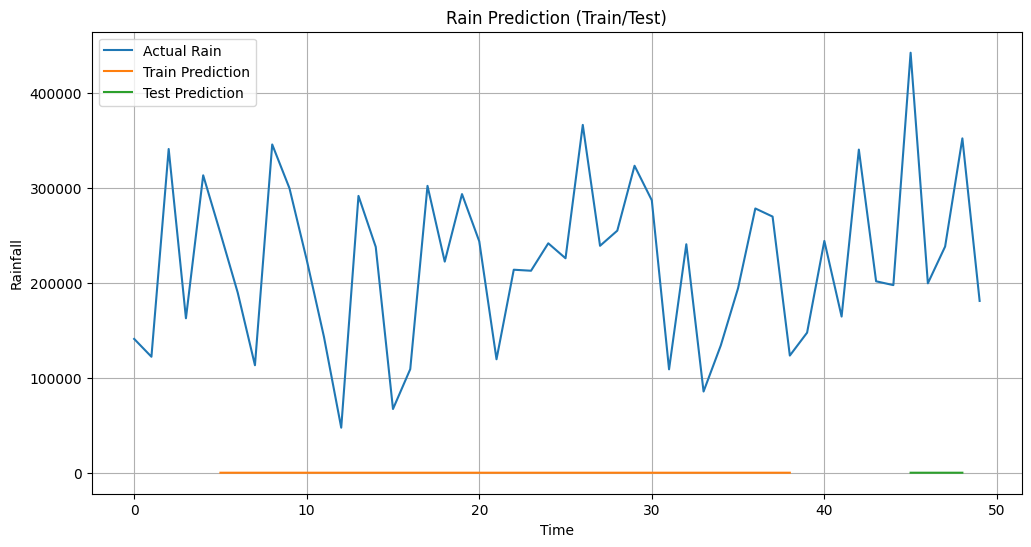

In [ ]:
# 시각화용 배열 초기화
trainRain_PredictPlot = np.empty_like(rain)
trainRain_PredictPlot[:, :] = np.nan
train_start = look_back
train_end = train_start + len(trainRain_Predict)
trainRain_PredictPlot[train_start:train_end, :] = trainRain_Predict

testRain_PredictPlot = np.empty_like(rain)
testRain_PredictPlot[:, :] = np.nan
test_start = train_end + look_back + 1
test_end = test_start + len(testRain_Predict)
testRain_PredictPlot[test_start:test_end, :] = testRain_Predict

# 시각화
plt.figure(figsize=(12, 6))
plt.plot(rain_scaler.inverse_transform(rain), label='Actual Rain')
plt.plot(trainRain_PredictPlot, label='Train Prediction')
plt.plot(testRain_PredictPlot, label='Test Prediction')
plt.title('Rain Prediction (Train/Test)')
plt.xlabel('Time')
plt.ylabel('Rainfall')
plt.legend()
plt.grid(True)
plt.show()